# Analiza danych NDR

Celem notebooka jest przygotowanie analizy danych z systemu NDR.

Dane wejściowe:
- network_logs.csv — surowe logi sieciowe,
- alerts.csv — alerty wygenerowane przez reguły detekcji,
- rules.csv — reguły detekcji,
- sensors.csv — sensory systemu,
- scenario_labels.csv — etykiety scenariuszy.

Pipeline analizy:

CSV → SQL Server → zapytania SQL → Python → tabele i wykresy

## 1. Import bibliotek i ustawienia projektu

W tej sekcji importujemy biblioteki, ustawiamy ścieżkę do danych i przygotowujemy połączenie z SQL Serverem.

In [1]:
from pathlib import Path
import urllib

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

data_path = Path(r"C:\Users\kaszi\Projekty moje\Projekt zespołowy sem 7\mock_dataset")

server = r".\OPTIMA"
db = "ndr_analysis"
driver = "ODBC Driver 17 for SQL Server"

params = urllib.parse.quote_plus(
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={db};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

with engine.connect() as conn:
    result = conn.execute(text("SELECT DB_NAME()"))
    print(result.fetchone()[0])

ndr_analysis


## 2. Utworzenie tabel SQL i import danych CSV

W tej sekcji tworzymy strukturę tabel w SQL Serverze, a następnie importujemy dane z plików CSV do bazy `ndr_analysis`.

Dzięki temu dalsza analiza będzie oparta na zapytaniach SQL, a Python będzie służył głównie do uruchamiania zapytań, przygotowania tabel wynikowych i wykresów.

In [2]:
sql = """
DROP TABLE IF EXISTS dbo.network_logs;
DROP TABLE IF EXISTS dbo.alerts;
DROP TABLE IF EXISTS dbo.rules;
DROP TABLE IF EXISTS dbo.sensors;
DROP TABLE IF EXISTS dbo.scenario_labels;

CREATE TABLE dbo.network_logs (
    id INT PRIMARY KEY,
    sensor_id INT,
    [timestamp] DATETIME2,
    src_ip VARCHAR(45),
    dst_ip VARCHAR(45),
    src_port INT,
    dst_port INT,
    protocol VARCHAR(20),
    flags VARCHAR(20),
    payload_size INT
);

CREATE TABLE dbo.alerts (
    id INT PRIMARY KEY,
    rule_id INT,
    rule_name VARCHAR(100),
    severity VARCHAR(20),
    status VARCHAR(50),
    src_ip VARCHAR(45),
    dst_ip VARCHAR(45),
    protocol VARCHAR(20),
    sensor_id VARCHAR(100),
    details VARCHAR(MAX),
    created_at DATETIME2,
    fingerprint VARCHAR(200),
    [count] INT,
    last_seen DATETIME2
);

CREATE TABLE dbo.rules (
    id INT PRIMARY KEY,
    name VARCHAR(100),
    type VARCHAR(100),
    enabled BIT,
    severity VARCHAR(20),
    description VARCHAR(MAX),
    created_at DATETIME2,
    hit_count INT,
    src_ip VARCHAR(500),
    dst_ip VARCHAR(45),
    dst_port INT,
    protocol VARCHAR(20),
    threshold INT,
    window_seconds INT
);

CREATE TABLE dbo.sensors (
    id INT PRIMARY KEY,
    name VARCHAR(100),
    location VARCHAR(100),
    status VARCHAR(50)
);

CREATE TABLE dbo.scenario_labels (
    scenario VARCHAR(50),
    src_ip VARCHAR(500),
    dst_ip VARCHAR(500),
    description VARCHAR(MAX),
    expected_rule VARCHAR(100),
    severity VARCHAR(20),
    starts_at DATETIME2,
    ends_at DATETIME2,
    log_count INT
);
"""

with engine.begin() as conn:
    conn.execute(text(sql))


logs = pd.read_csv(data_path / "network_logs.csv")
alerts = pd.read_csv(data_path / "alerts.csv")
rules = pd.read_csv(data_path / "rules.csv")
sensors = pd.read_csv(data_path / "sensors.csv")
labels = pd.read_csv(data_path / "scenario_labels.csv")


logs["timestamp"] = pd.to_datetime(logs["timestamp"], utc=True).dt.tz_localize(None)

alerts["created_at"] = pd.to_datetime(alerts["created_at"], utc=True).dt.tz_localize(None)
alerts["last_seen"] = pd.to_datetime(alerts["last_seen"], utc=True).dt.tz_localize(None)

rules["created_at"] = pd.to_datetime(rules["created_at"], utc=True).dt.tz_localize(None)

labels["starts_at"] = pd.to_datetime(labels["starts_at"], utc=True).dt.tz_localize(None)
labels["ends_at"] = pd.to_datetime(labels["ends_at"], utc=True).dt.tz_localize(None)


for col in ["dst_port", "threshold", "window_seconds"]:
    rules[col] = pd.to_numeric(rules[col], errors="coerce").astype("Int64")

labels["log_count"] = pd.to_numeric(labels["log_count"], errors="coerce").astype("Int64")


logs.to_sql("network_logs", engine, schema="dbo", if_exists="append", index=False)
alerts.to_sql("alerts", engine, schema="dbo", if_exists="append", index=False)
rules.to_sql("rules", engine, schema="dbo", if_exists="append", index=False)
sensors.to_sql("sensors", engine, schema="dbo", if_exists="append", index=False)
labels.to_sql("scenario_labels", engine, schema="dbo", if_exists="append", index=False)


query = """
SELECT 'network_logs' AS table_name, COUNT(*) AS rows_count FROM dbo.network_logs
UNION ALL
SELECT 'alerts', COUNT(*) FROM dbo.alerts
UNION ALL
SELECT 'rules', COUNT(*) FROM dbo.rules
UNION ALL
SELECT 'sensors', COUNT(*) FROM dbo.sensors
UNION ALL
SELECT 'scenario_labels', COUNT(*) FROM dbo.scenario_labels;
"""

check = pd.read_sql(query, engine)
check

,table_name,rows_count
0,network_logs,5000
1,alerts,36
2,rules,3
3,sensors,3
4,scenario_labels,37


## 3. Kontrola jakości danych

W tej sekcji sprawdzamy, czy dane zostały poprawnie załadowane do SQL Servera oraz przygotowujemy pierwszą tabelę KPI.

KPI pokazują podstawowe informacje o zbiorze:
- liczbę logów,
- liczbę alertów,
- zakres czasu,
- liczbę unikalnych adresów IP,
- liczbę reguł detekcji,
- liczbę scenariuszy.

In [3]:
query = """
SELECT 'Liczba logów sieciowych' AS metric, CAST(COUNT(*) AS VARCHAR(100)) AS value
FROM dbo.network_logs

UNION ALL

SELECT 'Liczba alertów', CAST(COUNT(*) AS VARCHAR(100))
FROM dbo.alerts

UNION ALL

SELECT 'Liczba reguł detekcji', CAST(COUNT(*) AS VARCHAR(100))
FROM dbo.rules

UNION ALL

SELECT 'Liczba sensorów', CAST(COUNT(*) AS VARCHAR(100))
FROM dbo.sensors

UNION ALL

SELECT 'Liczba scenariuszy', CAST(COUNT(*) AS VARCHAR(100))
FROM dbo.scenario_labels

UNION ALL

SELECT 'Unikalne src_ip w logach', CAST(COUNT(DISTINCT src_ip) AS VARCHAR(100))
FROM dbo.network_logs

UNION ALL

SELECT 'Unikalne src_ip w alertach', CAST(COUNT(DISTINCT src_ip) AS VARCHAR(100))
FROM dbo.alerts

UNION ALL

SELECT 'Początek zakresu logów', CONVERT(VARCHAR(100), MIN([timestamp]), 120)
FROM dbo.network_logs

UNION ALL

SELECT 'Koniec zakresu logów', CONVERT(VARCHAR(100), MAX([timestamp]), 120)
FROM dbo.network_logs

UNION ALL

SELECT 'Początek zakresu alertów', CONVERT(VARCHAR(100), MIN(created_at), 120)
FROM dbo.alerts

UNION ALL

SELECT 'Koniec zakresu alertów', CONVERT(VARCHAR(100), MAX(created_at), 120)
FROM dbo.alerts;
"""

kpi = pd.read_sql(query, engine)
kpi

,metric,value
0,Liczba logów sieciowych,5000
1,Liczba alertów,36
2,Liczba reguł detekcji,3
3,Liczba sensorów,3
4,Liczba scenariuszy,37
5,Unikalne src_ip w logach,16
6,Unikalne src_ip w alertach,8
7,Początek zakresu logów,2026-05-20 08:03:23
8,Koniec zakresu logów,2026-05-27 07:54:23
9,Początek zakresu alertów,2026-05-20 09:11:35


In [4]:
query = """
SELECT 'Alerty bez pasującej reguły' AS check_name, COUNT(*) AS rows_count
FROM dbo.alerts a
LEFT JOIN dbo.rules r
    ON a.rule_id = r.id
WHERE r.id IS NULL

UNION ALL

SELECT 'Logi bez pasującego sensora', COUNT(*)
FROM dbo.network_logs l
LEFT JOIN dbo.sensors s
    ON l.sensor_id = s.id
WHERE s.id IS NULL

UNION ALL

SELECT 'Alerty bez pasującego sensora', COUNT(*)
FROM dbo.alerts a
LEFT JOIN dbo.sensors s
    ON a.sensor_id = s.name
WHERE s.id IS NULL;
"""

quality = pd.read_sql(query, engine)
quality

,check_name,rows_count
0,Alerty bez pasującej reguły,0
1,Logi bez pasującego sensora,0
2,Alerty bez pasującego sensora,0


In [5]:
query = """
SELECT 'severity_alerts' AS area, severity AS category, COUNT(*) AS rows_count
FROM dbo.alerts
GROUP BY severity

UNION ALL

SELECT 'rules', rule_name, COUNT(*)
FROM dbo.alerts
GROUP BY rule_name

UNION ALL

SELECT 'scenarios', scenario, COUNT(*)
FROM dbo.scenario_labels
GROUP BY scenario;
"""

basic = pd.read_sql(query, engine)
basic

,area,category,rows_count
0,severity_alerts,critical,24
1,severity_alerts,high,12
2,rules,Blacklist IP,12
3,rules,Port Scan,12
4,rules,SSH Brute Force,12
5,scenarios,blacklist,12
6,scenarios,normal,1
7,scenarios,port-scan,12
8,scenarios,ssh-bruteforce,12


## 4. Liczba logów i alertów w czasie

W tej sekcji sprawdzamy, jak zmieniała się liczba logów sieciowych i alertów w czasie.

Logi pokazują ogólną aktywność sieciową, a alerty pokazują momenty, w których reguły detekcji wykryły podejrzane zachowanie.

In [6]:
chart_path = data_path.parent / "outputs" / "charts"
chart_path.mkdir(parents=True, exist_ok=True)

def save_chart(name):
    plt.tight_layout()
    plt.savefig(chart_path / f"{name}.png", dpi=300)
    plt.savefig(chart_path / f"{name}.svg")

query = """
WITH logs_by_hour AS (
    SELECT
        DATEADD(HOUR, DATEDIFF(HOUR, 0, [timestamp]), 0) AS event_hour,
        COUNT(*) AS logs_count
    FROM dbo.network_logs
    GROUP BY DATEADD(HOUR, DATEDIFF(HOUR, 0, [timestamp]), 0)
),

alerts_by_hour AS (
    SELECT
        DATEADD(HOUR, DATEDIFF(HOUR, 0, created_at), 0) AS event_hour,
        COUNT(*) AS alerts_count
    FROM dbo.alerts
    GROUP BY DATEADD(HOUR, DATEDIFF(HOUR, 0, created_at), 0)
)

SELECT
    COALESCE(l.event_hour, a.event_hour) AS event_hour,
    ISNULL(l.logs_count, 0) AS logs_count,
    ISNULL(a.alerts_count, 0) AS alerts_count
FROM logs_by_hour l
FULL OUTER JOIN alerts_by_hour a
    ON l.event_hour = a.event_hour
ORDER BY event_hour;
"""

time_data = pd.read_sql(query, engine)
time_data.head()

,event_hour,logs_count,alerts_count
0,2026-05-20 08:00:00,25,0
1,2026-05-20 09:00:00,30,1
2,2026-05-20 10:00:00,21,0
3,2026-05-20 11:00:00,23,0
4,2026-05-20 12:00:00,28,0


In [7]:
query = """
WITH logs_by_hour AS (
    SELECT
        DATEADD(HOUR, DATEDIFF(HOUR, 0, [timestamp]), 0) AS event_hour,
        COUNT(*) AS logs_count
    FROM dbo.network_logs
    GROUP BY DATEADD(HOUR, DATEDIFF(HOUR, 0, [timestamp]), 0)
),

alerts_by_hour AS (
    SELECT
        DATEADD(HOUR, DATEDIFF(HOUR, 0, created_at), 0) AS event_hour,
        COUNT(*) AS alerts_count
    FROM dbo.alerts
    GROUP BY DATEADD(HOUR, DATEDIFF(HOUR, 0, created_at), 0)
)

SELECT
    COALESCE(l.event_hour, a.event_hour) AS event_hour,
    ISNULL(l.logs_count, 0) AS logs_count,
    ISNULL(a.alerts_count, 0) AS alerts_count
FROM logs_by_hour l
FULL OUTER JOIN alerts_by_hour a
    ON l.event_hour = a.event_hour
ORDER BY event_hour;
"""

time_data = pd.read_sql(query, engine)
time_data.head()

,event_hour,logs_count,alerts_count
0,2026-05-20 08:00:00,25,0
1,2026-05-20 09:00:00,30,1
2,2026-05-20 10:00:00,21,0
3,2026-05-20 11:00:00,23,0
4,2026-05-20 12:00:00,28,0


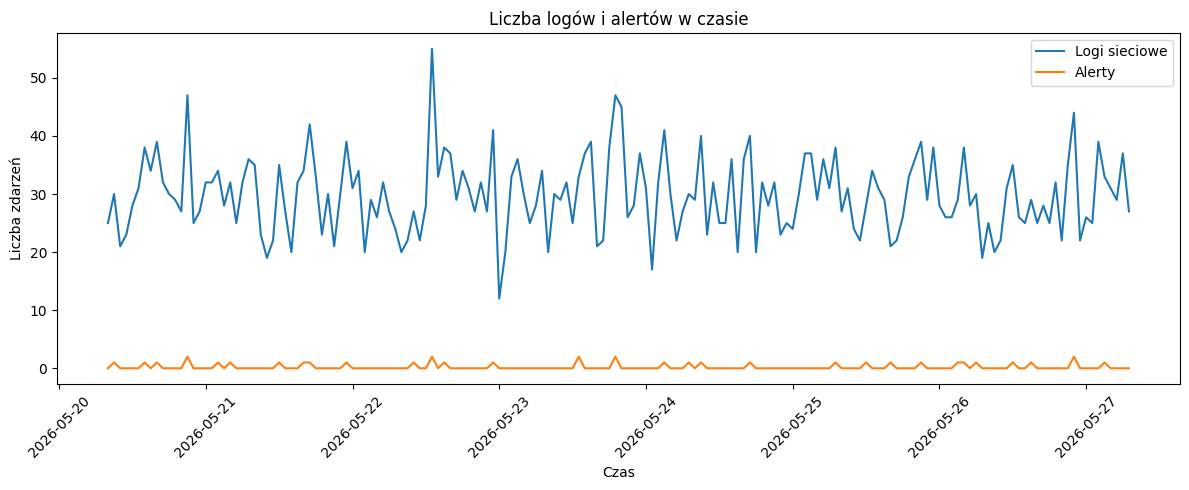

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(time_data["event_hour"], time_data["logs_count"], label="Logi sieciowe")
plt.plot(time_data["event_hour"], time_data["alerts_count"], label="Alerty")

plt.title("Liczba logów i alertów w czasie")
plt.xlabel("Czas")
plt.ylabel("Liczba zdarzeń")
plt.legend()
plt.xticks(rotation=45)

save_chart("logs_alerts_time")

plt.show()

## 5. Rozkład alertów po severity

W tej sekcji sprawdzamy, jaki poziom ważności mają wygenerowane alerty.

Severity oznacza ważność alertu, np.:
- critical — alert krytyczny,
- high — alert wysoki,
- info — alert informacyjny.

Ten widok pozwala szybko ocenić, czy dane zawierają głównie poważne zdarzenia, czy raczej niski poziom szumu.

In [9]:
query = """
SELECT
    severity,
    COUNT(*) AS alerts_count
FROM dbo.alerts
GROUP BY severity
ORDER BY
    CASE severity
        WHEN 'critical' THEN 1
        WHEN 'high' THEN 2
        WHEN 'medium' THEN 3
        WHEN 'low' THEN 4
        WHEN 'info' THEN 5
        ELSE 6
    END;
"""

severity = pd.read_sql(query, engine)
severity

,severity,alerts_count
0,critical,24
1,high,12


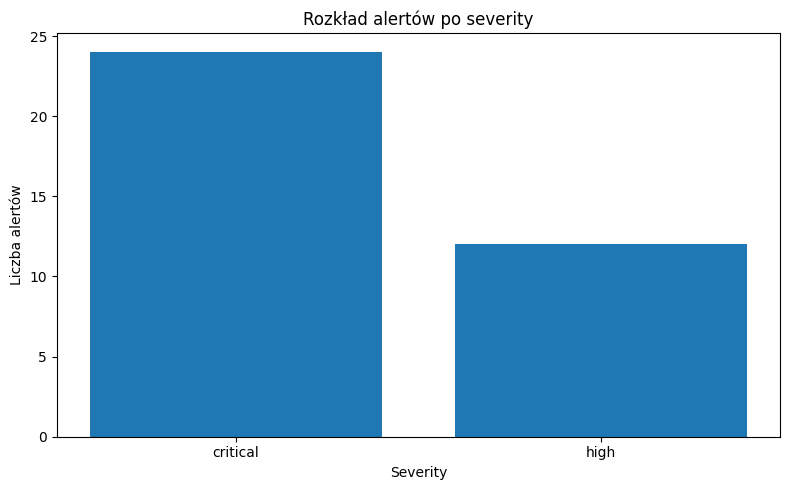

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(severity["severity"], severity["alerts_count"])

plt.title("Rozkład alertów po severity")
plt.xlabel("Severity")
plt.ylabel("Liczba alertów")

save_chart("alerts_severity")

plt.show()

W danych występuje 36 alertów: 24 alerty critical i 12 alertów high. Około 67% alertów ma poziom krytyczny, więc zbiór skupia się głównie na poważnych zdarzeniach bezpieczeństwa. Nie występują alerty info, low ani medium, więc analiza dotyczy przede wszystkim istotnych scenariuszy ataku.

## 6. Najbardziej podejrzane źródła IP

W tej sekcji sprawdzamy, które adresy `src_ip` generują najwięcej alertów.

Za bardziej podejrzane uznajemy te IP, które:
- generują dużo alertów,
- mają alerty `critical`,
- mają wysoką sumę pola `count`,
- uruchamiają więcej niż jedną regułę detekcji.

In [11]:
query = """
SELECT
    src_ip,
    COUNT(*) AS alerts_count,
    SUM([count]) AS hits_count,
    SUM(CASE WHEN severity = 'critical' THEN 1 ELSE 0 END) AS critical_alerts,
    SUM(CASE WHEN severity = 'high' THEN 1 ELSE 0 END) AS high_alerts,
    COUNT(DISTINCT rule_name) AS rules_count,
    MIN(created_at) AS first_seen,
    MAX(last_seen) AS last_seen
FROM dbo.alerts
GROUP BY src_ip
ORDER BY
    critical_alerts DESC,
    alerts_count DESC,
    hits_count DESC;
"""

ip_alerts = pd.read_sql(query, engine)

ip_alerts["risk_score"] = (
    ip_alerts["critical_alerts"] * 3
    + ip_alerts["high_alerts"] * 2
    + ip_alerts["hits_count"] * 0.2
    + ip_alerts["rules_count"]
).round(1)

ip_alerts = ip_alerts.sort_values(
    by=["risk_score", "alerts_count", "hits_count"],
    ascending=False
)

ip_alerts

,src_ip,alerts_count,hits_count,critical_alerts,high_alerts,rules_count,first_seen,last_seen,risk_score
0,10.10.40.44,7,22,7,0,1,2026-05-21 12:16:45,2026-05-26 12:46:08,26.4
5,10.10.30.23,8,35,0,8,1,2026-05-20 09:11:35,2026-05-26 22:59:02,24.0
1,198.51.100.23,7,7,7,0,1,2026-05-22 10:58:31,NaT,23.4
2,203.0.113.66,5,5,5,0,1,2026-05-21 02:14:21,NaT,17.0
3,10.10.40.18,3,11,3,0,1,2026-05-20 21:04:26,2026-05-24 07:44:51,12.2
6,10.10.30.42,3,13,0,3,1,2026-05-20 21:02:49,2026-05-26 15:56:09,9.6
4,10.10.40.91,2,6,2,0,1,2026-05-24 09:14:16,2026-05-26 22:09:49,8.2
7,10.10.30.77,1,2,0,1,1,2026-05-23 19:21:00,2026-05-23 19:21:30,3.4


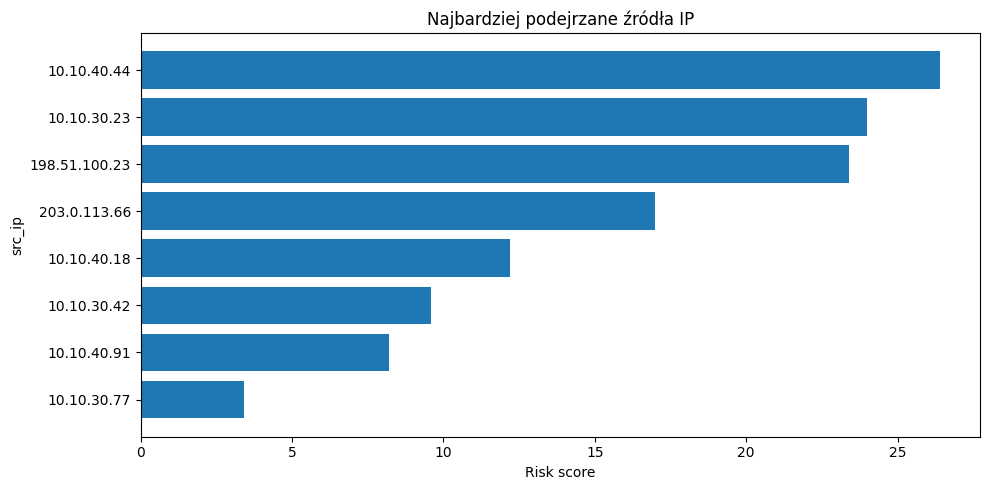

In [12]:
top_ip = ip_alerts.head(10).sort_values("risk_score")

plt.figure(figsize=(10, 5))

plt.barh(top_ip["src_ip"], top_ip["risk_score"])

plt.title("Najbardziej podejrzane źródła IP")
plt.xlabel("Risk score")
plt.ylabel("src_ip")

save_chart("top_suspicious_ips")

plt.show()

Najwyższy wynik ryzyka uzyskał adres `10.10.40.44`, który wygenerował 7 alertów krytycznych i 22 trafienia reguł. Drugim istotnym źródłem jest `10.10.30.23`, które ma największą liczbę alertów i trafień, ale są to alerty poziomu `high`, dlatego jego wynik ryzyka jest niższy niż źródeł z alertami krytycznymi.

Warto zauważyć, że każde podejrzane IP uruchomiło tylko jedną regułę detekcji. Oznacza to, że źródła są raczej powiązane z konkretnymi scenariuszami ataku, a nie z wieloma różnymi typami aktywności.

## 7. Najczęściej uruchamiane reguły detekcji

W tej sekcji sprawdzamy, które reguły detekcji generują najwięcej alertów i ile łącznie trafień mają w polu `count`.

Sama liczba alertów nie zawsze wystarcza, bo jeden alert może reprezentować większą liczbę wykrytych zdarzeń. Dlatego porównujemy:
- liczbę alertów,
- sumę trafień `count`,
- poziom severity,
- liczbę źródłowych adresów IP.

In [13]:
query = """
SELECT
    rule_name,
    severity,
    COUNT(*) AS alerts_count,
    SUM([count]) AS hits_count,
    COUNT(DISTINCT src_ip) AS src_ip_count,
    MIN(created_at) AS first_seen,
    MAX(last_seen) AS last_seen
FROM dbo.alerts
GROUP BY rule_name, severity
ORDER BY hits_count DESC, alerts_count DESC;
"""

rules_summary = pd.read_sql(query, engine)
rules_summary

,rule_name,severity,alerts_count,hits_count,src_ip_count,first_seen,last_seen
0,Port Scan,high,12,50,3,2026-05-20 09:11:35,2026-05-26 22:59:02
1,SSH Brute Force,critical,12,39,3,2026-05-20 21:04:26,2026-05-26 22:09:49
2,Blacklist IP,critical,12,12,2,2026-05-21 02:14:21,NaT


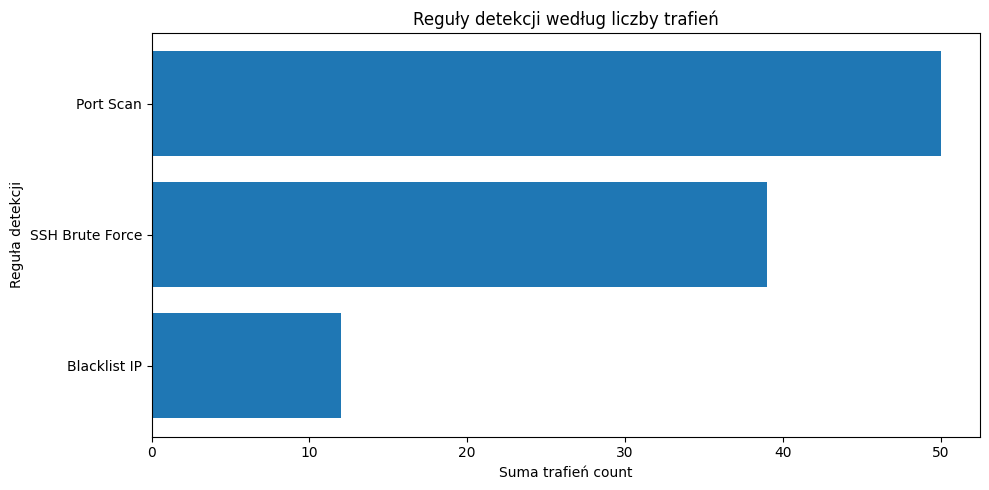

In [14]:
rules_plot = rules_summary.sort_values("hits_count")

plt.figure(figsize=(10, 5))

plt.barh(rules_plot["rule_name"], rules_plot["hits_count"])

plt.title("Reguły detekcji według liczby trafień")
plt.xlabel("Suma trafień count")
plt.ylabel("Reguła detekcji")

save_chart("rules_hits_count")

plt.show()

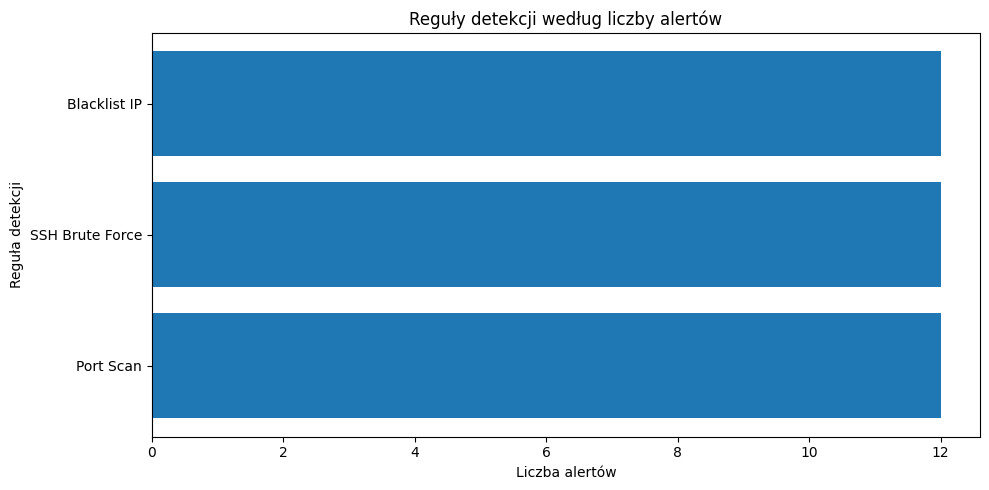

In [15]:
rules_plot = rules_summary.sort_values("alerts_count")

plt.figure(figsize=(10, 5))

plt.barh(rules_plot["rule_name"], rules_plot["alerts_count"])

plt.title("Reguły detekcji według liczby alertów")
plt.xlabel("Liczba alertów")
plt.ylabel("Reguła detekcji")

save_chart("rules_alerts_count")

plt.show()

In [16]:
rules_summary

,rule_name,severity,alerts_count,hits_count,src_ip_count,first_seen,last_seen
0,Port Scan,high,12,50,3,2026-05-20 09:11:35,2026-05-26 22:59:02
1,SSH Brute Force,critical,12,39,3,2026-05-20 21:04:26,2026-05-26 22:09:49
2,Blacklist IP,critical,12,12,2,2026-05-21 02:14:21,NaT


Każda z trzech reguł wygenerowała po 12 alertów, więc sama liczba alertów nie różnicuje ich aktywności. Różnica pojawia się dopiero po analizie pola `count`, które pokazuje liczbę wykrytych trafień.

Najwięcej trafień miała reguła `Port Scan` — 50. Następnie `SSH Brute Force` — 39 trafień. Reguła `Blacklist IP` wygenerowała 12 trafień, czyli najmniej z analizowanych reguł.

W raporcie końcowym warto więc pokazywać reguły głównie według `hits_count`, a nie tylko według liczby alertów.

## 8. Normal traffic vs scenariusze ataku

W tej sekcji porównujemy ruch normalny ze scenariuszami ataku opisanymi w `scenario_labels`.

Porównanie wykonujemy na podstawie:
- liczby logów,
- liczby źródłowych adresów IP,
- liczby docelowych adresów IP,
- liczby portów docelowych,
- średniego rozmiaru pakietu,
- liczby alertów powiązanych ze scenariuszem.

In [17]:
query = """
WITH log_scenarios AS (
    SELECT
        l.id,
        l.[timestamp],
        l.src_ip,
        l.dst_ip,
        l.dst_port,
        l.protocol,
        l.payload_size,
        COALESCE(sl.scenario, 'unlabeled') AS scenario
    FROM dbo.network_logs l
    LEFT JOIN dbo.scenario_labels sl
        ON l.[timestamp] BETWEEN sl.starts_at AND sl.ends_at
        AND (
            sl.src_ip = l.src_ip
            OR sl.src_ip LIKE '%' + l.src_ip + '%'
        )
),

alert_scenarios AS (
    SELECT
        COALESCE(sl.scenario, 'unlabeled') AS scenario,
        COUNT(*) AS alerts_count
    FROM dbo.alerts a
    LEFT JOIN dbo.scenario_labels sl
        ON a.created_at BETWEEN sl.starts_at AND sl.ends_at
        AND (
            sl.src_ip = a.src_ip
            OR sl.src_ip LIKE '%' + a.src_ip + '%'
        )
    GROUP BY COALESCE(sl.scenario, 'unlabeled')
)

SELECT
    l.scenario,
    COUNT(*) AS logs_count,
    COUNT(DISTINCT l.src_ip) AS src_ip_count,
    COUNT(DISTINCT l.dst_ip) AS dst_ip_count,
    COUNT(DISTINCT l.dst_port) AS dst_port_count,
    AVG(CAST(l.payload_size AS FLOAT)) AS avg_payload_size,
    ISNULL(MAX(a.alerts_count), 0) AS alerts_count
FROM log_scenarios l
LEFT JOIN alert_scenarios a
    ON l.scenario = a.scenario
GROUP BY l.scenario
ORDER BY
    CASE WHEN l.scenario = 'normal' THEN 1 ELSE 0 END,
    alerts_count DESC,
    logs_count DESC;
"""

scenario_summary = pd.read_sql(query, engine)
scenario_summary

,scenario,logs_count,src_ip_count,dst_ip_count,dst_port_count,avg_payload_size,alerts_count
0,port-scan,98,3,5,12,64.000000,12
1,ssh-bruteforce,87,3,5,1,64.000000,12
2,blacklist,12,2,5,3,512.000000,12
3,normal,4803,8,5,9,934.650635,0


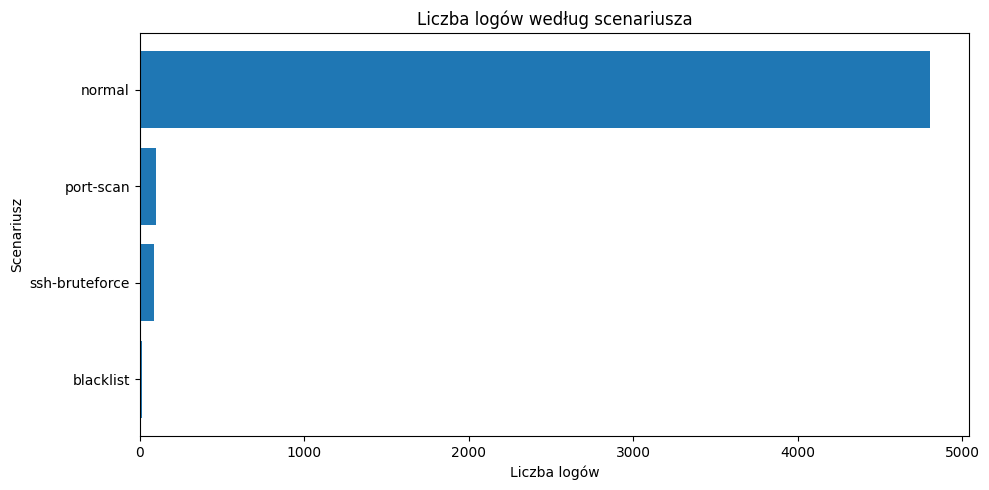

In [18]:
plot_data = scenario_summary.sort_values("logs_count")

plt.figure(figsize=(10, 5))

plt.barh(plot_data["scenario"], plot_data["logs_count"])

plt.title("Liczba logów według scenariusza")
plt.xlabel("Liczba logów")
plt.ylabel("Scenariusz")

save_chart("scenario_logs_count")

plt.show()

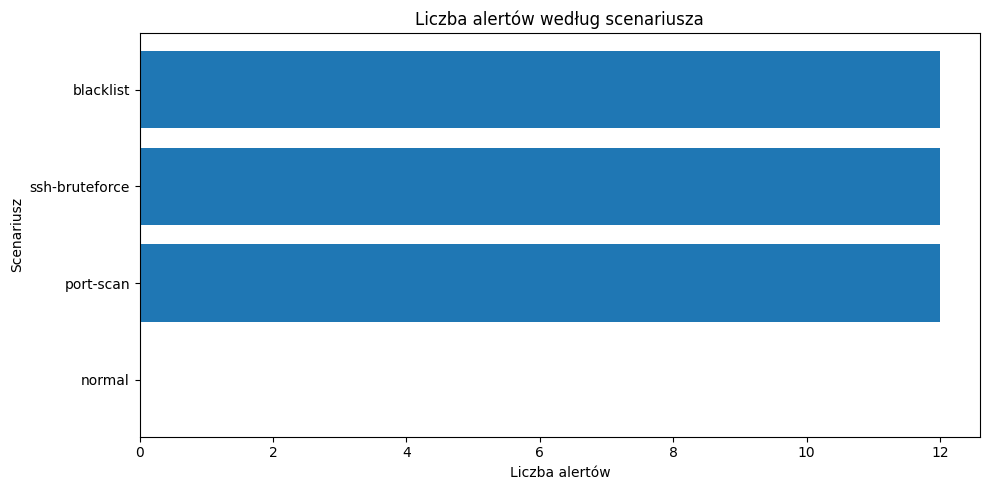

In [19]:
plot_data = scenario_summary.sort_values("alerts_count")

plt.figure(figsize=(10, 5))

plt.barh(plot_data["scenario"], plot_data["alerts_count"])

plt.title("Liczba alertów według scenariusza")
plt.xlabel("Liczba alertów")
plt.ylabel("Scenariusz")

save_chart("scenario_alerts_count")

plt.show()

In [20]:
scenario_summary

,scenario,logs_count,src_ip_count,dst_ip_count,dst_port_count,avg_payload_size,alerts_count
0,port-scan,98,3,5,12,64.000000,12
1,ssh-bruteforce,87,3,5,1,64.000000,12
2,blacklist,12,2,5,3,512.000000,12
3,normal,4803,8,5,9,934.650635,0


Ruch normalny stanowi zdecydowaną większość danych — 4803 logi i 0 alertów. Scenariusze ataku mają dużo mniejszą liczbę logów, ale generują alerty.

`Port Scan` wyróżnia się największą liczbą różnych portów docelowych, co pasuje do charakterystyki skanowania portów. `SSH Brute Force` ma tylko jeden port docelowy, co wskazuje na powtarzalne próby połączeń z jedną usługą. Scenariusz `Blacklist` ma najmniej logów, ale każdy z nich prowadzi do alertu.

Widać więc wyraźną różnicę między ruchem normalnym a scenariuszami ataku: normalny ruch jest liczny, ale nie generuje alertów, natomiast ataki są krótsze i bardziej skoncentrowane.

## 9. Piki i anomalie czasowe

W tej sekcji sprawdzamy, czy w danych występują godziny z nietypowo wysoką liczbą logów oraz kiedy pojawiały się alerty.

Do wskazania pików logów używamy `z_score`, czyli miary pokazującej, jak bardzo dana godzina odbiega od średniej liczby logów.

In [21]:
time_data["logs_mean"] = time_data["logs_count"].mean()
time_data["logs_std"] = time_data["logs_count"].std()

time_data["z_score"] = (
    (time_data["logs_count"] - time_data["logs_mean"]) / time_data["logs_std"]
).round(2)

anomaly_hours = time_data[time_data["z_score"] >= 2].copy()

anomaly_hours = anomaly_hours[
    ["event_hour", "logs_count", "alerts_count", "z_score"]
].sort_values("z_score", ascending=False)

anomaly_hours

,event_hour,logs_count,alerts_count,z_score
53,2026-05-22 13:00:00,55,2,3.83
13,2026-05-20 21:00:00,47,2,2.61
83,2026-05-23 19:00:00,47,2,2.61
84,2026-05-23 20:00:00,45,0,2.31
158,2026-05-26 22:00:00,44,2,2.16


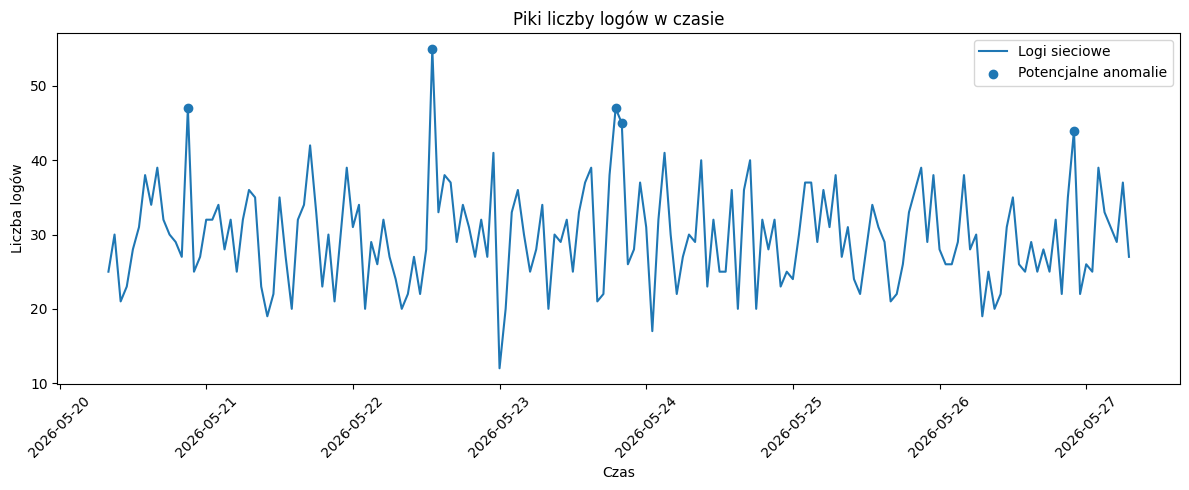

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(time_data["event_hour"], time_data["logs_count"], label="Logi sieciowe")

plt.scatter(
    anomaly_hours["event_hour"],
    anomaly_hours["logs_count"],
    label="Potencjalne anomalie"
)

plt.title("Piki liczby logów w czasie")
plt.xlabel("Czas")
plt.ylabel("Liczba logów")
plt.legend()
plt.xticks(rotation=45)

save_chart("logs_anomalies")

plt.show()

In [23]:
alert_hours = time_data[time_data["alerts_count"] > 0].copy()

alert_hours = alert_hours[
    ["event_hour", "logs_count", "alerts_count"]
].sort_values("alerts_count", ascending=False)

alert_hours.head(10)

,event_hour,logs_count,alerts_count
13,2026-05-20 21:00:00,47,2
53,2026-05-22 13:00:00,55,2
77,2026-05-23 13:00:00,33,2
158,2026-05-26 22:00:00,44,2
83,2026-05-23 19:00:00,47,2
8,2026-05-20 16:00:00,39,1
18,2026-05-21 02:00:00,34,1
28,2026-05-21 12:00:00,35,1
20,2026-05-21 04:00:00,32,1
32,2026-05-21 16:00:00,34,1


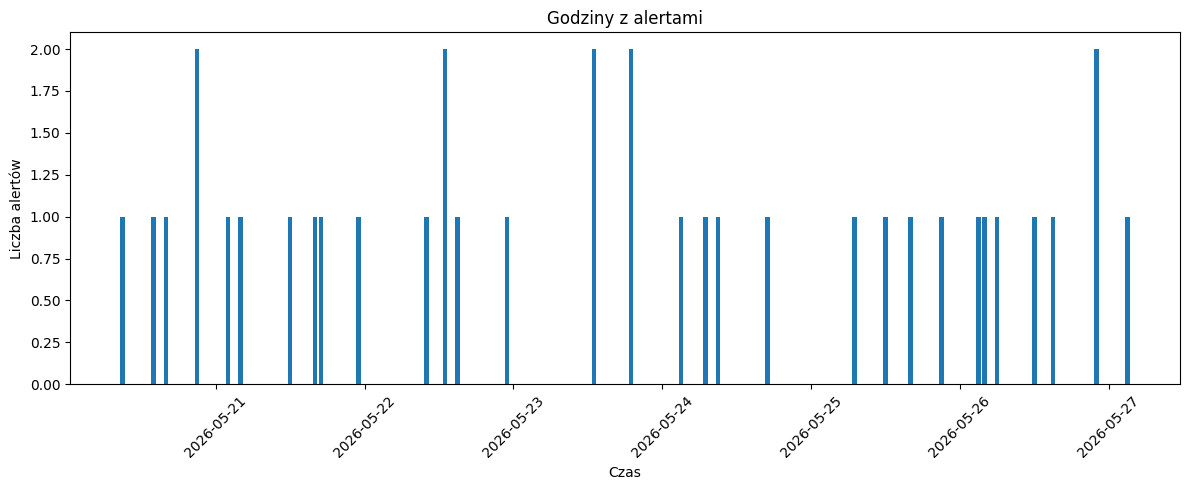

In [24]:
plt.figure(figsize=(12, 5))

plt.bar(alert_hours["event_hour"], alert_hours["alerts_count"], width=0.03)

plt.title("Godziny z alertami")
plt.xlabel("Czas")
plt.ylabel("Liczba alertów")
plt.xticks(rotation=45)

save_chart("alert_hours")

plt.show()

W danych widać kilka godzin z podwyższoną liczbą logów. Największy pik wystąpił `2026-05-22 13:00:00`, gdzie odnotowano 55 logów i 2 alerty. Wartość `z_score = 3.83` oznacza, że ta godzina mocno odbiega od typowego poziomu ruchu.

Nie każdy pik liczby logów oznacza jednak alerty. Przykładowo `2026-05-23 20:00:00` miała 45 logów i `z_score = 2.31`, ale 0 alertów. Oznacza to, że sama duża liczba logów nie wystarcza do uznania zdarzenia za incydent.

Alerty pojawiały się głównie pojedynczo lub po 2 w jednej godzinie. Najwięcej alertów w jednej godzinie wynosiło 2, m.in. dla `2026-05-23 19:00:00`, `2026-05-26 22:00:00`, `2026-05-20 21:00:00`, `2026-05-23 13:00:00` i `2026-05-22 13:00:00`.

In [25]:
kpi_report = kpi.copy()
top_ip_report = ip_alerts.head(10).copy()
rules_report = rules_summary.copy()
scenarios_report = scenario_summary.copy()

kpi_report

,metric,value
0,Liczba logów sieciowych,5000
1,Liczba alertów,36
2,Liczba reguł detekcji,3
3,Liczba sensorów,3
4,Liczba scenariuszy,37
5,Unikalne src_ip w logach,16
6,Unikalne src_ip w alertach,8
7,Początek zakresu logów,2026-05-20 08:03:23
8,Koniec zakresu logów,2026-05-27 07:54:23
9,Początek zakresu alertów,2026-05-20 09:11:35


In [26]:
table_path = data_path.parent / "outputs" / "tables"
table_path.mkdir(parents=True, exist_ok=True)

kpi_report.to_csv(table_path / "kpi_report.csv", index=False, encoding="utf-8-sig")
top_ip_report.to_csv(table_path / "top_suspicious_ips.csv", index=False, encoding="utf-8-sig")
rules_report.to_csv(table_path / "rules_summary.csv", index=False, encoding="utf-8-sig")
scenarios_report.to_csv(table_path / "scenario_summary.csv", index=False, encoding="utf-8-sig")

print("Tabele zapisane do folderu:", table_path)

Tabele zapisane do folderu: C:\Users\kaszi\Projekty moje\Projekt zespołowy sem 7\outputs\tables


In [27]:
top_ip_report

,src_ip,alerts_count,hits_count,critical_alerts,high_alerts,rules_count,first_seen,last_seen,risk_score
0,10.10.40.44,7,22,7,0,1,2026-05-21 12:16:45,2026-05-26 12:46:08,26.4
5,10.10.30.23,8,35,0,8,1,2026-05-20 09:11:35,2026-05-26 22:59:02,24.0
1,198.51.100.23,7,7,7,0,1,2026-05-22 10:58:31,NaT,23.4
2,203.0.113.66,5,5,5,0,1,2026-05-21 02:14:21,NaT,17.0
3,10.10.40.18,3,11,3,0,1,2026-05-20 21:04:26,2026-05-24 07:44:51,12.2
6,10.10.30.42,3,13,0,3,1,2026-05-20 21:02:49,2026-05-26 15:56:09,9.6
4,10.10.40.91,2,6,2,0,1,2026-05-24 09:14:16,2026-05-26 22:09:49,8.2
7,10.10.30.77,1,2,0,1,1,2026-05-23 19:21:00,2026-05-23 19:21:30,3.4


In [28]:
rules_report

,rule_name,severity,alerts_count,hits_count,src_ip_count,first_seen,last_seen
0,Port Scan,high,12,50,3,2026-05-20 09:11:35,2026-05-26 22:59:02
1,SSH Brute Force,critical,12,39,3,2026-05-20 21:04:26,2026-05-26 22:09:49
2,Blacklist IP,critical,12,12,2,2026-05-21 02:14:21,NaT


In [29]:
scenarios_report

,scenario,logs_count,src_ip_count,dst_ip_count,dst_port_count,avg_payload_size,alerts_count
0,port-scan,98,3,5,12,64.000000,12
1,ssh-bruteforce,87,3,5,1,64.000000,12
2,blacklist,12,2,5,3,512.000000,12
3,normal,4803,8,5,9,934.650635,0


## 11. Wnioski końcowe

Analizowany zbiór obejmuje 5000 logów sieciowych oraz 36 alertów z okresu od `2026-05-20` do `2026-05-27`. Dane pochodzą z 3 sensorów i obejmują 3 reguły detekcji oraz 37 opisanych scenariuszy.

W alertach występują tylko dwa poziomy ważności: `critical` oraz `high`. Alertów krytycznych jest 24, a alertów wysokich 12. Oznacza to, że zbiór skupia się na istotnych zdarzeniach bezpieczeństwa, a nie na alertach informacyjnych.

Najbardziej podejrzanym źródłem IP jest `10.10.40.44`, które wygenerowało 7 alertów krytycznych i 22 trafienia reguł. Wysoko w rankingu znalazły się też adresy `10.10.30.23` oraz `198.51.100.23`. Każde z podejrzanych źródeł uruchamiało tylko jedną regułę, więc aktywność IP była powiązana raczej z konkretnym typem ataku niż z wieloma różnymi technikami.

Każda reguła detekcji wygenerowała po 12 alertów, dlatego sama liczba alertów nie wystarcza do oceny aktywności reguł. Lepszą miarą jest suma pola `count`. Według tej miary najaktywniejsza była reguła `Port Scan` z 50 trafieniami, następnie `SSH Brute Force` z 39 trafieniami, a najmniej trafień miała reguła `Blacklist IP` — 12.

Porównanie scenariuszy pokazuje wyraźną różnicę między ruchem normalnym a atakami. Ruch normalny obejmuje 4803 logi i nie wygenerował żadnego alertu. Scenariusze ataku mają mniej logów, ale generują alerty. `Port Scan` wyróżnia się dużą liczbą różnych portów docelowych, `SSH Brute Force` skupia się na jednym porcie, a `Blacklist` ma najmniej logów, ale każdy z nich prowadzi do alertu.

W danych widoczne są również piki czasowe. Największy pik liczby logów wystąpił `2026-05-22 13:00:00`, gdzie odnotowano 55 logów i 2 alerty. Nie każdy wzrost liczby logów oznacza jednak incydent — przykładowo `2026-05-23 20:00:00` miała podwyższoną liczbę logów, ale 0 alertów.

Najważniejszy wniosek: system detekcji skutecznie rozróżnia ruch normalny od scenariuszy ataku. Ataki są krótsze, bardziej skoncentrowane i generują alerty, podczas gdy ruch normalny jest liczny, ale nie powoduje wykryć.